# Catalogue Copy Count Analysis

## Library Imports

Import necessary libraries for data processing, visualization, statistics, and probability distribution fitting

In [11]:
# ============================================================================
# LIBRARY IMPORTS
# Import all necessary packages for data manipulation, visualization,
# API requests, and statistical analysis.
# ============================================================================

# To handle dataframe objects
import pandas as pd

# To visualize data and create plots
import matplotlib.pyplot as plt

# To suppress warnings during execution
import warnings

# To perform probability distribution fitting and numerical operations
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.special import gammaln, beta as beta_func

Suppress all warnings to maintain clean output during notebook execution

In [12]:
# Suppress all warnings while executing the code to keep output clean
warnings.filterwarnings('ignore')

## Helper Functions

### Probability Law Conformity Functions

In [13]:
# ============================================================================
# PARAMETRIC BOOTSTRAP GOODNESS-OF-FIT (VALID FOR ALL MODELS)
# ============================================================================

def bootstrap_gof(data, fit_func, loglik_func, simulate_func, B=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(data)

    # Fit to observed data
    fit_obs = fit_func(data)
    theta_hat = fit_obs["params"]

    # Observed discrepancy
    T_obs = -loglik_func(data, theta_hat)

    # Bootstrap distribution
    T_boot = np.empty(B)
    for b in range(B):
        sim_data = simulate_func(theta_hat, n, rng)
        fit_b = fit_func(sim_data)
        T_boot[b] = -loglik_func(sim_data, fit_b["params"])

    p_value = np.mean(T_boot >= T_obs)

    return p_value


# ============================================================================
# LOG-LIKELIHOODS + SIMULATORS
# ============================================================================

def geom_loglik(data, params):
    p = params["p"]
    return np.sum(np.log(p * (1 - p) ** (data - 1)))

def geom_sim(params, n, rng):
    return rng.geometric(params["p"], size=n)


def geom_mix_loglik(data, params):
    w, p1, p2 = params["w"], params["p1"], params["p2"]
    g1 = p1 * (1 - p1) ** (data - 1)
    g2 = p2 * (1 - p2) ** (data - 1)
    return np.sum(np.log(np.clip(w * g1 + (1 - w) * g2, 1e-12, 1)))

def geom_mix_sim(params, n, rng):
    z = rng.uniform(size=n) < params["w"]
    x = np.empty(n, dtype=int)
    x[z] = rng.geometric(params["p1"], size=z.sum())
    x[~z] = rng.geometric(params["p2"], size=(~z).sum())
    return x


def ztp_loglik(data, params):
    lam = params["lambda"]
    return np.sum(stats.poisson.logpmf(data, lam) - np.log(1 - np.exp(-lam)))

def ztp_sim(params, n, rng):
    lam = params["lambda"]
    x = rng.poisson(lam, size=n)
    while np.any(x == 0):
        x[x == 0] = rng.poisson(lam, size=(x == 0).sum())
    return x


def ztnb_loglik(data, params):
    r, p = params["r"], params["p"]
    ll = stats.nbinom.logpmf(data, r, p)
    ll -= np.log(1 - stats.nbinom.pmf(0, r, p))
    return np.sum(ll)

def ztnb_sim(params, n, rng):
    r, p = params["r"], params["p"]
    x = rng.negative_binomial(r, p, size=n)
    while np.any(x == 0):
        x[x == 0] = rng.negative_binomial(r, p, size=(x == 0).sum())
    return x


# ============================================================================
# FIT FUNCTIONS (UNCHANGED MLE LOGIC, CLEAN OUTPUT)
# ============================================================================

def fit_geometric(data):
    p = np.clip(1 / data.mean(), 1e-3, 0.999)
    return {"params": {"p": p}}

def fit_geometric_mixture(data):
    def nll(params):
        w, p1, p2 = params
        if not (0 < w < 1 and 0 < p1 < 1 and 0 < p2 < 1):
            return 1e10
        g1 = p1 * (1 - p1) ** (data - 1)
        g2 = p2 * (1 - p2) ** (data - 1)
        return -np.sum(np.log(np.clip(w * g1 + (1 - w) * g2, 1e-12, 1)))

    p0 = 1 / data.mean()
    res = minimize(nll, [0.5, p0 * 0.7, p0 * 1.3],
                   bounds=[(0.01, 0.99)] * 3, method="L-BFGS-B")
    return {"params": dict(zip(["w", "p1", "p2"], res.x))}


def fit_ztp(data):
    lam = data.mean()
    return {"params": {"lambda": lam}}

def fit_ztnb(data):
    def nll(params):
        r, p = params
        if r <= 0 or not (0 < p < 1):
            return 1e10
        ll = stats.nbinom.logpmf(data, r, p)
        ll -= np.log(1 - stats.nbinom.pmf(0, r, p))
        return -np.sum(ll)

    res = minimize(nll, [1.0, 0.5],
                   bounds=[(0.1, 50), (0.01, 0.99)], method="L-BFGS-B")
    return {"params": dict(zip(["r", "p"], res.x))}


# ============================================================================
# FIT ALL DISTRIBUTIONS (VALID GOF)
# ============================================================================

def fit_all_distributions(data):
    models = {
        "Geometric": (fit_geometric, geom_loglik, geom_sim),
        "Geometric Mixture": (fit_geometric_mixture, geom_mix_loglik, geom_mix_sim),
        "Zero-Truncated Poisson": (fit_ztp, ztp_loglik, ztp_sim),
        "Zero-Truncated NB": (fit_ztnb, ztnb_loglik, ztnb_sim),
    }

    results = {}
    print("\nFitting distributions (VALID bootstrap GOF)...")
    print("=" * 60)

    for name, (fit_f, ll_f, sim_f) in models.items():
        print(f"Fitting {name}...")
        fit = fit_f(data)
        p_val = bootstrap_gof(data, fit_f, ll_f, sim_f, B=500)
        results[name] = {"params": fit["params"], "gof_p_value": p_val}

    return results


## Copy Count Distribution Visualisation

Load library catalogue data and display raw distribution of copy counts in a histogram

In [14]:
# ============================================================================
# DATA LOADING
# Load the raw library catalogue dataset and set column names.
# ============================================================================

# Retrieve the dataset from the csv file
df = pd.read_csv('../../data/processed/library_catalogue.csv', header='infer', na_values=None)

# Apply the respective columns to the dataframe
df.columns = ['ISBN/ISSN','Title','Author','Copy Count']

# Display basic info about the dataset
print(f'Number of instances = {df.shape[0]}')
print(f'Number of attributes = {df.shape[1]}')
df.head()

Number of instances = 565
Number of attributes = 4


,ISBN/ISSN,Title,Author,Copy Count
0,9782855576558,10 CLÉS POUR COMPRENDRE LE SOL,RAOUL CALVET,3
1,9782100824199,100 FICHES POUR BIEN DÉMARRER EN PRÉPA,MARIE-VIRGINIE SPELLER,2
2,9782100725106,50 [CINQUANTE]CLÉS POUR COMPRENDRE LA PHYSIQUE,"BAKER, JOANNE",2
3,9782729839406,8 ANS DE PROBLÈMES CORRIGÉS DE MATHÉMATIQUES P...,FRANCHINI JEAN,2
4,9780321794772,A FIRST COURSE IN PROBABILITY,"ROSS, SHELDON M.",3


Plot histogram showing the raw distribution of book copy counts across the library

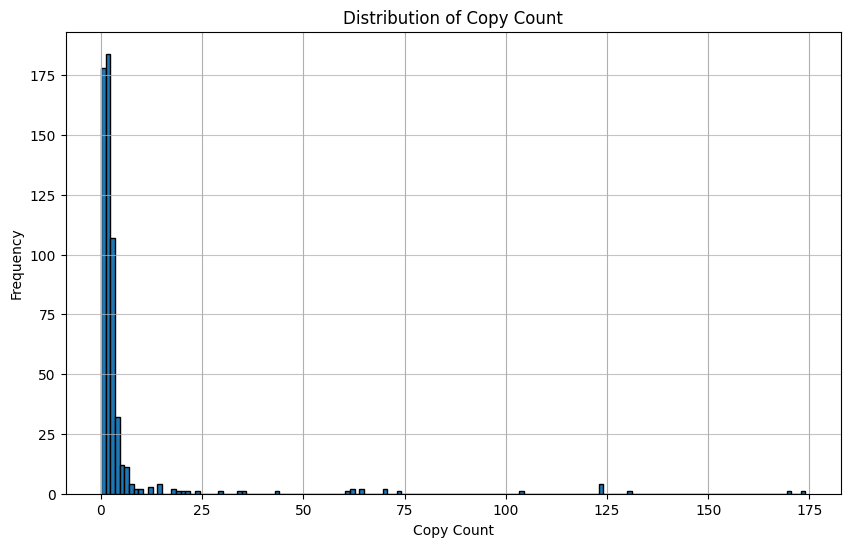

In [15]:
# Plot histogram of raw Copy Count values
plt.figure(figsize=(10, 6))

df['Copy Count'].hist(bins=150, edgecolor='black')

plt.title('Distribution of Copy Count')
plt.xlabel('Copy Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Copy Count Distribution Fitting

Fit multiple probability distributions to copy count data and evaluate goodness-of-fit using bootstrap methods

Data summary:
  n = 489
  min = 1, max = 174
  mean = 6.282, var = 360.976
  skew = 6.047
  Variance/Mean ratio: 57.46x

Fitting distributions (VALID bootstrap GOF)...
Fitting Geometric...
Fitting Geometric Mixture...
Fitting Zero-Truncated Poisson...
Fitting Zero-Truncated NB...

GOODNESS-OF-FIT RESULTS (PARAMETRIC BOOTSTRAP)

Distribution                   GOF p-value     Status
------------------------------------------------------------
Geometric                      0.4820          ✓ Plausible
Geometric Mixture              0.4220          ✓ Plausible
Zero-Truncated Poisson         0.0000          ✗ Reject
Zero-Truncated NB              1.0000          ⚠ Possibly overfitting


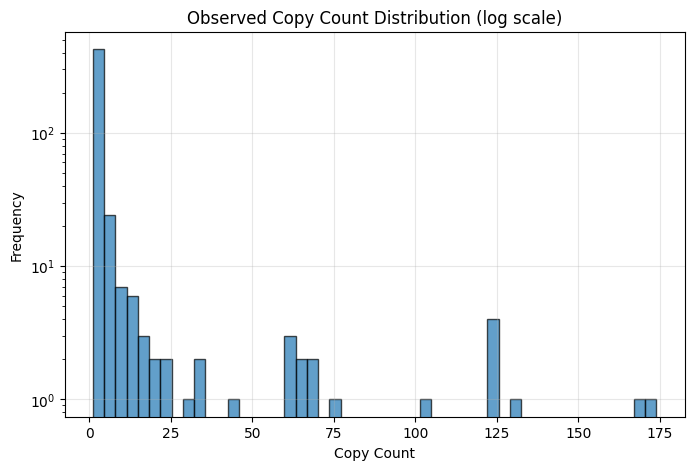


Interpretation guide:
p < 0.05  → model is statistically rejected
0.1–0.9   → model is plausible
p ≈ 1.0   → model likely too flexible (mixtures warning)


In [16]:
# ============================================================================
# DISTRIBUTION FITTING EXECUTION (VALID BOOTSTRAP GOF)
# ============================================================================

# -------------------- Configuration --------------------
PLOT_RANGE = 300

# -------------------- Data Preparation --------------------
data = df['Copy Count'].values
data = data[data > 0]   # IMPORTANT: enforce zero-truncation

n = len(data)

print("Data summary:")
print(f"  n = {n}")
print(f"  min = {data.min()}, max = {data.max()}")
print(f"  mean = {data.mean():.3f}, var = {data.var():.3f}")
print(f"  skew = {stats.skew(data):.3f}")
print(f"  Variance/Mean ratio: {data.var()/data.mean():.2f}x")

# -------------------- Fit All Distributions --------------------
results = fit_all_distributions(data)

# -------------------- Display Results --------------------
print("\n" + "="*80)
print("GOODNESS-OF-FIT RESULTS (PARAMETRIC BOOTSTRAP)")
print("="*80)

print(f"\n{'Distribution':<30} {'GOF p-value':<15} {'Status'}")
print("-"*60)

for name, res in results.items():
    p = res["gof_p_value"]

    if p < 0.05:
        status = "✗ Reject"
    elif p > 0.95:
        status = "⚠ Possibly overfitting"
    else:
        status = "✓ Plausible"

    print(f"{name:<30} {p:<15.4f} {status}")

# -------------------- Visualization --------------------
# Histogram of observed data
plt.figure(figsize=(8, 5))
plt.hist(data, bins=50, log=True, alpha=0.7, edgecolor="black")
plt.title("Observed Copy Count Distribution (log scale)")
plt.xlabel("Copy Count")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# -------------------- Final Interpretation --------------------
print("\nInterpretation guide:")
print("p < 0.05  → model is statistically rejected")
print("0.1–0.9   → model is plausible")
print("p ≈ 1.0   → model likely too flexible (mixtures warning)")

Extract and interpret parameters from the best-fit Geometric Mixture model, explaining mixture weights and component properties

In [17]:
# ============================================================================
# GEOMETRIC MIXTURE PARAMETER INTERPRETATION
# Extract and interpret the fitted parameters from the best-fit model.
# ============================================================================

# Extract fitted parameters from Geometric Mixture results
params = results['Geometric Mixture']['params']
w = params['w']    # Mixing weight: proportion of data from Component 1
p1 = params['p1']  # Success probability for Component 1
p2 = params['p2']  # Success probability for Component 2

# Display parameter interpretation
print(f"Geometric Mixture Parameters:")
print(f"  Weight w = {w:.3f} ({w*100:.1f}% of books follow Component 1)")
print(f"  Component 1 (Geometric): p = {p1:.3f} → Mean = {1/p1:.1f} copies")
print(f"  Component 2 (Geometric): p = {p2:.3f} → Mean = {1/p2:.1f} copies")

# Calculate and compare expected vs actual mean
overall_mean = w * (1/p1) + (1-w) * (1/p2)
print(f"  Overall expected mean = {overall_mean:.1f} copies (actual mean: {data.mean():.1f})")

Geometric Mixture Parameters:
  Weight w = 0.071 (7.1% of books follow Component 1)
  Component 1 (Geometric): p = 0.018 → Mean = 56.2 copies
  Component 2 (Geometric): p = 0.401 → Mean = 2.5 copies
  Overall expected mean = 6.3 copies (actual mean: 6.3)


Visualize the fitted mixture model components and compare expected vs observed frequencies

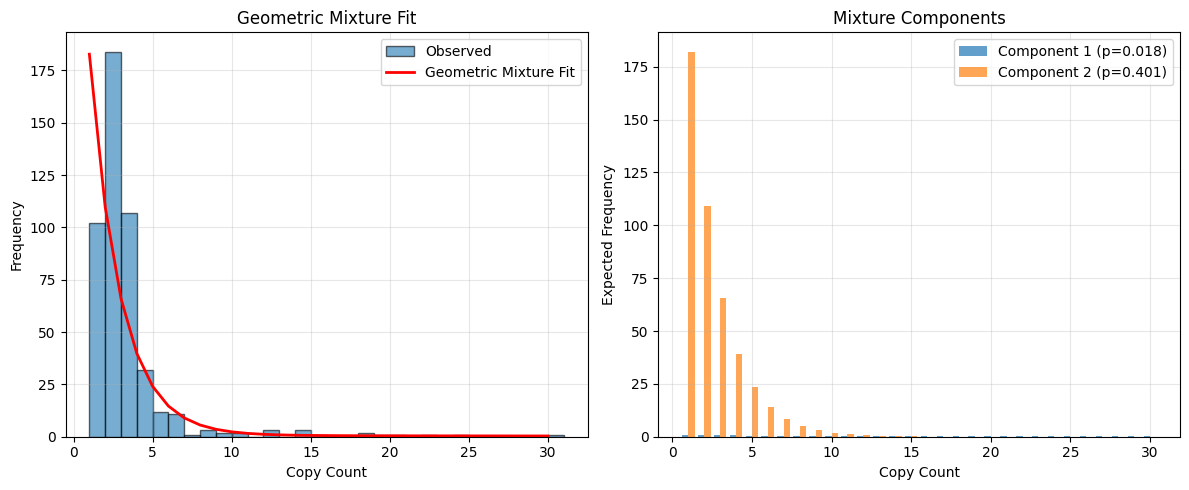

In [18]:
# ============================================================================
# MIXTURE COMPONENT VISUALIZATION (CORRECT — NO EXPECTED COUNTS STORED)
# ============================================================================

# Range to visualize
k = np.arange(1, 31)

# Mixture PMF
pmf_mix = (
    w * p1 * (1 - p1) ** (k - 1)
    + (1 - w) * p2 * (1 - p2) ** (k - 1)
)

# Convert to expected frequencies
expected_mix = pmf_mix * n

# Individual components
geom1 = w * p1 * (1 - p1) ** (k - 1) * n
geom2 = (1 - w) * p2 * (1 - p2) ** (k - 1) * n

# --------------------------------------------------------------------
# Plot
# --------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------- Plot 1: Overall Fit --------------------
axes[0].hist(
    data,
    bins=np.arange(1, 32),
    alpha=0.6,
    edgecolor="black",
    label="Observed"
)
axes[0].plot(k, expected_mix, "r-", lw=2, label="Geometric Mixture Fit")
axes[0].set_title("Geometric Mixture Fit")
axes[0].set_xlabel("Copy Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -------------------- Plot 2: Individual Components --------------------
axes[1].bar(k - 0.2, geom1, width=0.4, alpha=0.7,
            label=f"Component 1 (p={p1:.3f})")
axes[1].bar(k + 0.2, geom2, width=0.4, alpha=0.7,
            label=f"Component 2 (p={p2:.3f})")
axes[1].set_title("Mixture Components")
axes[1].set_xlabel("Copy Count")
axes[1].set_ylabel("Expected Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Perform comprehensive goodness-of-fit diagnostics including CDF comparison, QQ plots, PP plots, and simulation-based tests

Creating CDF comparison plot...


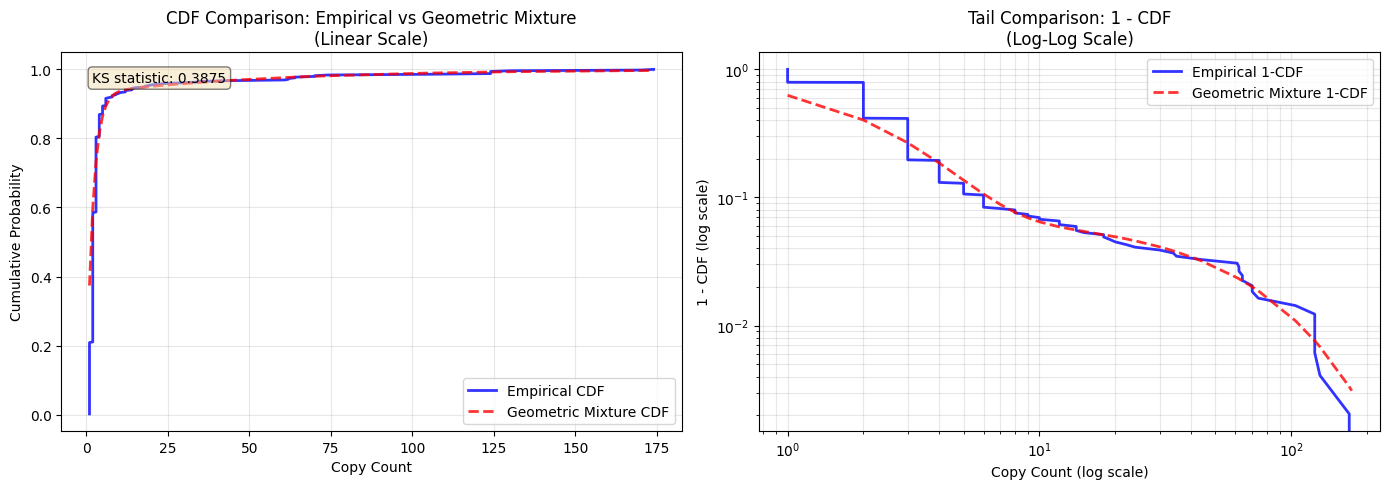

In [19]:
# ============================================================================
# COMPREHENSIVE GOODNESS-OF-FIT DIAGNOSTICS
# Create CDF comparison, QQ plots, PP plots, and simulation-based tests
# to thoroughly evaluate the Geometric Mixture model fit.
# ============================================================================

def geometric_mixture_cdf(k, w, p1, p2):
    """
    CDF of a two-component geometric mixture at integer point k.
    Geometric CDF: P(X <= k) = 1 - (1-p)^k
    """
    cdf1 = 1 - (1 - p1) ** k
    cdf2 = 1 - (1 - p2) ** k
    return w * cdf1 + (1 - w) * cdf2

# ==================== 1. CDF COMPARISON PLOT ====================
print("Creating CDF comparison plot...")

# Calculate empirical CDF (ECDF)
sorted_data = np.sort(data)
ecdf = np.arange(1, n + 1) / n

# Calculate theoretical CDF at each data point
theoretical_cdf = np.array([geometric_mixture_cdf(k, w, p1, p2) for k in sorted_data])

# Calculate KS statistic (maximum deviation between CDFs)
ks_stat = np.max(np.abs(ecdf - theoretical_cdf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1a: CDF comparison (linear scale)
axes[0].plot(sorted_data, ecdf, 'b-', linewidth=2, label='Empirical CDF', alpha=0.8)
axes[0].plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Geometric Mixture CDF', alpha=0.8)
axes[0].set_xlabel('Copy Count')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('CDF Comparison: Empirical vs Geometric Mixture\n(Linear Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'KS statistic: {ks_stat:.4f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 1b: Tail comparison (log-log scale)
axes[1].loglog(sorted_data, 1 - ecdf, 'b-', linewidth=2, label='Empirical 1-CDF', alpha=0.8)
axes[1].loglog(sorted_data, 1 - theoretical_cdf, 'r--', linewidth=2, 
              label='Geometric Mixture 1-CDF', alpha=0.8)
axes[1].set_xlabel('Copy Count (log scale)')
axes[1].set_ylabel('1 - CDF (log scale)')
axes[1].set_title('Tail Comparison: 1 - CDF\n(Log-Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()



Creating QQ plot...


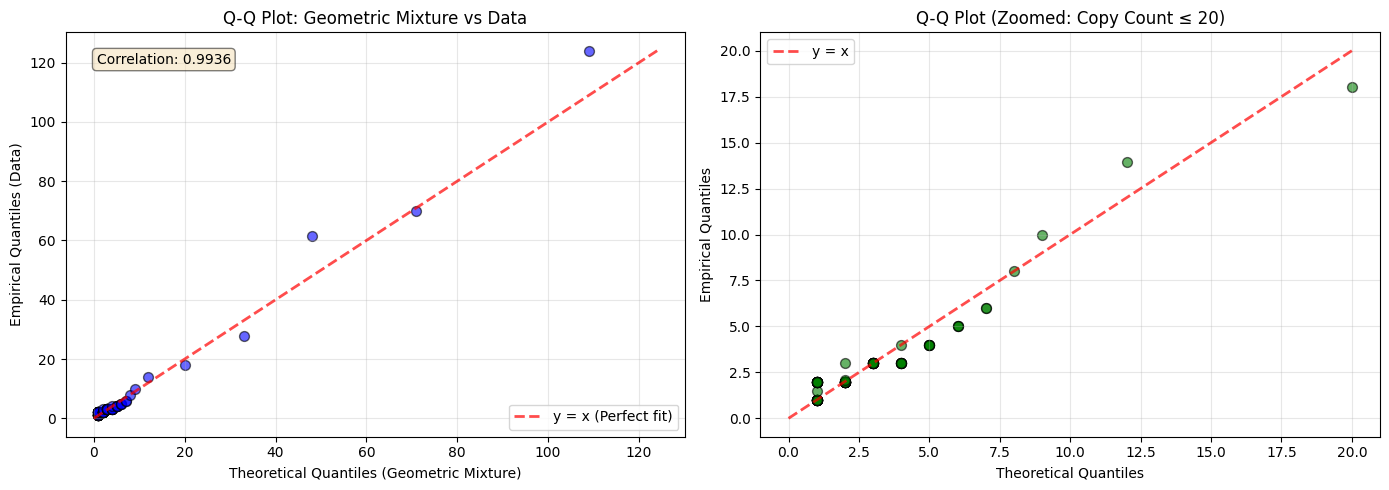

In [20]:
# ==================== 2. QUANTILE-QUANTILE (QQ) PLOT ====================
print("\nCreating QQ plot...")

def geometric_mixture_quantile(prob, w, p1, p2):
    """
    Inverse CDF (quantile function) for a geometric mixture.
    Uses binary search since no closed-form solution exists.
    """
    if prob <= 0:
        return 1
    if prob >= 1:
        return np.inf
    
    # Binary search for the quantile
    low, high = 1, 10000
    while low < high:
        mid = (low + high) // 2
        if geometric_mixture_cdf(mid, w, p1, p2) < prob:
            low = mid + 1
        else:
            high = mid
    return low

# Create percentile grid (avoid 0 and 1 for finite quantiles)
percentiles = np.linspace(0.01, 0.99, 100)

# Calculate empirical and theoretical quantiles
empirical_quantiles = np.percentile(data, percentiles * 100)
theoretical_quantiles = np.array([geometric_mixture_quantile(q, w, p1, p2) for q in percentiles])

# Calculate QQ correlation
qq_corr = np.corrcoef(theoretical_quantiles, empirical_quantiles)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2a: Full QQ plot
max_val_qq = max(np.max(theoretical_quantiles), np.max(empirical_quantiles))
axes[0].scatter(theoretical_quantiles, empirical_quantiles, alpha=0.6, 
               color='blue', edgecolor='black', s=50)
axes[0].plot([0, max_val_qq], [0, max_val_qq], 'r--', linewidth=2, alpha=0.7, label='y = x (Perfect fit)')
axes[0].set_xlabel('Theoretical Quantiles (Geometric Mixture)')
axes[0].set_ylabel('Empirical Quantiles (Data)')
axes[0].set_title('Q-Q Plot: Geometric Mixture vs Data')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'Correlation: {qq_corr:.4f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2b: Zoomed QQ plot (focus on common values)
zoom_threshold = 20
zoom_mask = (theoretical_quantiles <= zoom_threshold) & (empirical_quantiles <= zoom_threshold)
axes[1].scatter(theoretical_quantiles[zoom_mask], empirical_quantiles[zoom_mask], 
               alpha=0.6, color='green', edgecolor='black', s=50)
axes[1].plot([0, zoom_threshold], [0, zoom_threshold], 'r--', linewidth=2, alpha=0.7, label='y = x')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Empirical Quantiles')
axes[1].set_title(f'Q-Q Plot (Zoomed: Copy Count ≤ {zoom_threshold})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Creating PP plot...


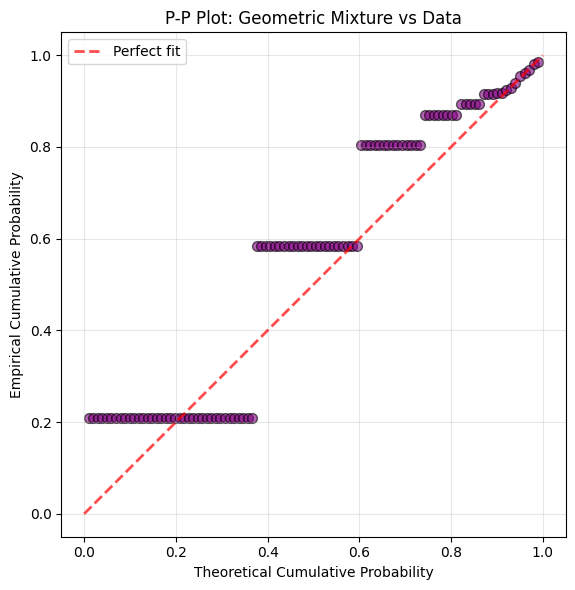

In [21]:
# ==================== 3. PP PLOT (Probability-Probability) ====================
print("\nCreating PP plot...")

# Calculate empirical probabilities at theoretical quantiles
empirical_probs_at_theoretical = np.array([
    np.mean(data <= geometric_mixture_quantile(prob, w, p1, p2))
    for prob in percentiles
])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(percentiles, empirical_probs_at_theoretical, alpha=0.6, 
          color='purple', edgecolor='black', s=50)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
ax.set_xlabel('Theoretical Cumulative Probability')
ax.set_ylabel('Empirical Cumulative Probability')
ax.set_title('P-P Plot: Geometric Mixture vs Data')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


Performing simulation-based goodness-of-fit test...
  Completed 200/1000 simulations...
  Completed 400/1000 simulations...
  Completed 600/1000 simulations...
  Completed 800/1000 simulations...
  Completed 1000/1000 simulations...

Subsample-based goodness-of-fit (n=270):
  Observed KS statistic (subsample): 0.3700
  Observed KS statistic (full data): 0.3875
  Simulated p-value: 1.0000
  Mean KS from simulations: 0.3700
  95% of simulated KS are below: 0.3700


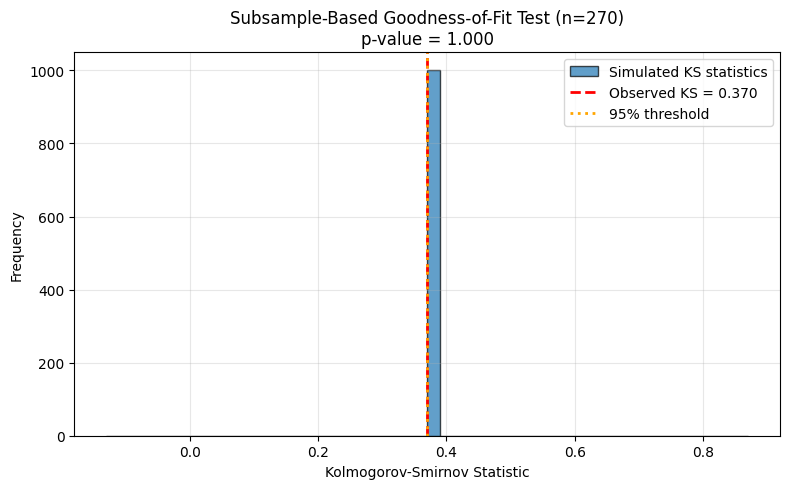


Note: Using subsample of 270 instead of full n=489
This avoids the 'large sample problem' where even tiny deviations cause p=0


In [45]:
# ==================== 4. SIMULATION-BASED GOODNESS-OF-FIT TEST ====================
print("\nPerforming simulation-based goodness-of-fit test...")

def simulate_geometric_mixture(n, w, p1, p2, seed=None):
    """
    Simulate n samples from a two-component geometric mixture.
    """
    rng = np.random.default_rng(seed)
    # Assign each sample to a component
    component = rng.uniform(size=n) < w
    samples = np.empty(n, dtype=int)
    samples[component] = rng.geometric(p1, size=component.sum())
    samples[~component] = rng.geometric(p2, size=(~component).sum())
    return samples

# ============================================================================
# SUBSAMPLE-BASED SIMULATION TEST (More robust for large datasets)
# With large n, even tiny deviations cause p=0. Subsampling gives fairer test.
# ============================================================================

subsample_size = min(270, n)  # Use subsample for fairer statistical test
n_simulations = 1000
simulated_ks_stats = []

# Draw a single subsample from observed data for comparison
np.random.seed(42)
subsample_idx = np.random.choice(n, size=subsample_size, replace=False)
subsample_data = data[subsample_idx]

# Calculate observed KS for subsample
sub_sorted = np.sort(subsample_data)
sub_ecdf = np.arange(1, subsample_size + 1) / subsample_size
sub_theoretical = np.array([geometric_mixture_cdf(k, w, p1, p2) for k in sub_sorted])
ks_stat_sub = np.max(np.abs(sub_ecdf - sub_theoretical))

for i in range(n_simulations):
    # Simulate data from fitted model (same size as subsample)
    sim_data = simulate_geometric_mixture(subsample_size, w, p1, p2)
    
    # Calculate simulated ECDF and theoretical CDF
    sim_sorted = np.sort(sim_data)
    sim_ecdf = np.arange(1, subsample_size + 1) / subsample_size
    sim_theoretical_cdf = np.array([geometric_mixture_cdf(k, w, p1, p2) for k in sim_sorted])
    
    # Store KS statistic
    simulated_ks_stats.append(np.max(np.abs(sim_ecdf - sim_theoretical_cdf)))
    
    if (i + 1) % 200 == 0:
        print(f"  Completed {i+1}/{n_simulations} simulations...")

simulated_ks_stats = np.array(simulated_ks_stats)

# Calculate simulation-based p-value using subsample KS
p_value_sim = np.mean(simulated_ks_stats >= ks_stat_sub)

print(f"\nSubsample-based goodness-of-fit (n={subsample_size}):")
print(f"  Observed KS statistic (subsample): {ks_stat_sub:.4f}")
print(f"  Observed KS statistic (full data): {ks_stat:.4f}")
print(f"  Simulated p-value: {p_value_sim:.4f}")
print(f"  Mean KS from simulations: {np.mean(simulated_ks_stats):.4f}")
print(f"  95% of simulated KS are below: {np.percentile(simulated_ks_stats, 95):.4f}")

# Plot simulation results
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(simulated_ks_stats, bins=50, alpha=0.7, edgecolor='black', label='Simulated KS statistics')
ax.axvline(x=ks_stat_sub, color='red', linewidth=2, linestyle='--', label=f'Observed KS = {ks_stat_sub:.3f}')
ax.axvline(x=np.percentile(simulated_ks_stats, 95), color='orange', linewidth=2, linestyle=':', label='95% threshold')
ax.set_xlabel('Kolmogorov-Smirnov Statistic')
ax.set_ylabel('Frequency')
ax.set_title(f'Subsample-Based Goodness-of-Fit Test (n={subsample_size})\np-value = {p_value_sim:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Note about the approach
print(f"\nNote: Using subsample of {subsample_size} instead of full n={n}")
print(f"This avoids the 'large sample problem' where even tiny deviations cause p=0")